In [73]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

构造人造数据集

In [74]:
def synthetic_data(w,b,num_examples):
    """生成Y=Xw+b+噪声"""
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

features中的每一行都包含一个二维数据样本，labels中的每一行都包含一维标签值（一个标量）

In [75]:
print("features:",features[0],"\nlabel:",labels[0])

features: tensor([ 0.4596, -1.1180]) 
label: tensor([8.9324])


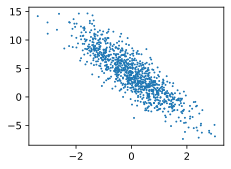

In [76]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

定义一个data_iter函数，该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [77]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield feature[batch_indices],labels[batch_indices] #迭代
batch_size=10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-2.5265, -0.2042],
        [-0.3685,  0.6521],
        [ 0.2412, -1.3785],
        [-0.6640,  0.8428],
        [-1.6575, -0.5948],
        [-0.9717,  0.3151],
        [ 0.1149,  0.4440],
        [-0.0723,  0.4208],
        [-0.2058, -0.9609],
        [-0.1768,  1.7433]]) 
 tensor([[ 5.8753],
        [ 6.1564],
        [-1.3209],
        [ 6.5537],
        [ 2.5063],
        [-0.4617],
        [ 3.0187],
        [ 5.9071],
        [ 9.9291],
        [11.2579]])


定义初始化模型参数

In [78]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

定义模型

In [79]:
def linreg(X,w,b):
    """线性回归模型"""
    return torch.matmul(X,w)+b

定义损失函数

In [80]:
def squared_loss(y_hat,y):
    """均方损失"""
    return (y_hat-y.reshape(y_hat.shape))**2/2

定义优化算法

In [81]:
def sgd(params,lr,batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for params in params:
            params -=lr*params.grad/batch_size
            params.grad.zero_()

训练过程

In [82]:
lr=0.03
num_epochs=10
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y) #"X和y的小批量损失"
        l.sum().backward()
        sgd([w,b],lr,batch_size) #使用参数的梯度更新参数
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch{epoch+1},loss{float(train_l.mean()):f}')

epoch1,loss8.395942
epoch2,loss8.103974
epoch3,loss7.967287
epoch4,loss8.791649
epoch5,loss8.439943
epoch6,loss8.271927
epoch7,loss8.249381
epoch8,loss8.530787
epoch9,loss8.041368
epoch10,loss8.483449


比较真实参数和通过训练学习到的参数来评估训练的成功程度

In [83]:
print(f'w的估计误差:{true_w-w.reshape(true_w.shape)}')
print(f'b的估计误差:{true_b-b}')

w的估计误差:tensor([ 2.2156, -3.4919], grad_fn=<SubBackward0>)
b的估计误差:tensor([0.2619], grad_fn=<RsubBackward1>)
